# Statistcal Analysis:

## 1. Cha-square Test:

In [1]:
# import libraries:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [2]:
# load the dataset of titanic:
df= sns.load_dataset('titanic')
df.head()


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [3]:
# create a contigencency table:
contingency_table= pd.crosstab(df['sex'], df['survived'])
contingency_table

survived,0,1
sex,,
female,81,233
male,468,109


In [7]:
# perform chi-square test:
chi2, p, dof, expected = stats.chi2_contingency(contingency_table)
print(f"Chi-square Statistic: {chi2}")
print(f"P-value: {p}")
print(f"Degrees of Freedom: {dof}")
print("Expected Frequencies:")

Chi-square Statistic: 260.71702016732104
P-value: 1.1973570627755645e-58
Degrees of Freedom: 1
Expected Frequencies:


---

# 2. Normal Distribution Test:

In [8]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


<Axes: xlabel='age', ylabel='Count'>

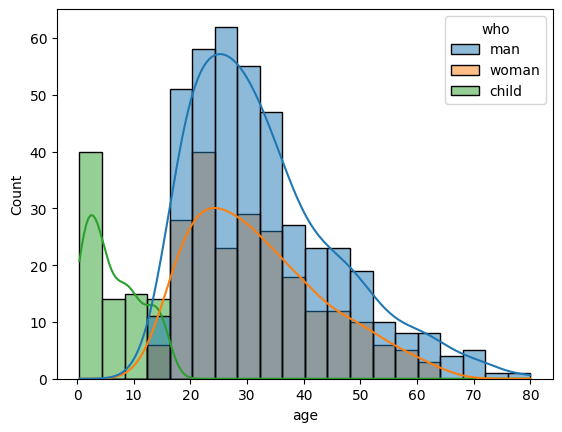

In [13]:
# graphical representation of age distribution
sns.histplot(data=df, x='age', kde=True,hue='who')

## Alterenative Hypotesis:


In [16]:
# shipero wilk test:
statistic, p_value = stats.shapiro(df['age'].dropna())
# print the statistic and p-value
print(f"Shapiro-Wilk Statistic: {statistic}")
print(f"P-value: {p_value}")
# print the results using if else statement:
alpha = 0.05
if p_value > alpha:
    print("Fail to reject the null hypothesis: Data is normally distributed")
else:
    print("Reject the null hypothesis: Data is not normally distributed")

Shapiro-Wilk Statistic: 0.9814577414504954
P-value: 7.337348958673592e-08
Reject the null hypothesis: Data is not normally distributed


<Axes: xlabel='fare', ylabel='Count'>

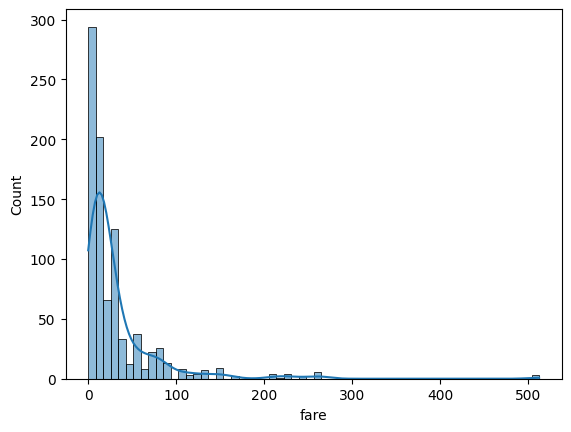

In [18]:
sns.histplot(data=df, x='fare', kde=True)

---

# t-test:

In [20]:
# simple data:
x=[1,2,3,4,5]

# known population mean:
mu=3
# perform one sample t-test:
t_statistic, p_value = stats.ttest_1samp(x, mu)

# print the t-statistic and p-value
print(f"T-statistic: {t_statistic}")
print(f"P-value: {p_value}")

# print the results using if else statement: 
alpha = 0.05 
if p_value > alpha:
    print("Fail to reject the null hypothesis: Sample mean is equal to population mean")
else:
    print("Reject the null hypothesis: Sample mean is not equal to population mean")

T-statistic: 0.0
P-value: 1.0
Fail to reject the null hypothesis: Sample mean is equal to population mean


2. Two Sample T-test (independed)
   

In [22]:
# two sample t-test (independed)
group1 = [5, 6, 7, 8, 9]
group2 = [10, 11, 12, 13, 14]

# perform two sample t-test:
t_statistic, p_value = stats.ttest_ind(group1, group2)

# print the t-statistic and p-value
print(f"T-statistic: {t_statistic}")
print(f"P-value: {p_value}") 

# print the results using if else statement:
alpha = 0.05
if p_value > alpha:
    print("Fail to reject the null hypothesis: group1 means of both groups are equal")
else:
    print("Reject the null hypothesis: group2 means of both groups are not equal")


T-statistic: -5.0
P-value: 0.001052825793366539
Reject the null hypothesis: group2 means of both groups are not equal


---


# ANOVA
Anslysis of Variance:

# 1. one-way ANOVA

In [23]:
# sample data for ANOVA:

a=[5, 6, 7, 8, 9]
b=[10, 11, 12, 13, 14, 15, 16]
c=[15, 16, 17, 18, 19, 20] 

# perform one-way ANOVA:
f_statistic, p_value = stats.f_oneway(a, b, c)

# print the F-statistic and p-value
print(f"F-statistic: {f_statistic}")
print(f"P-value: {p_value}")

# print the results using if else statement:
alpha = 0.05
if p_value > alpha:
    print("Fail to reject the null hypothesis: All group means are equal")
else:
    print("Reject the null hypothesis: At least one group mean is different")

F-statistic: 40.67567567567568
P-value: 8.744819848061139e-07
Reject the null hypothesis: At least one group mean is different


---

In [30]:
import statsmodels.api as sm
from statsmodels.multivariate.manova import MANOVA

# MANVA:

In [31]:
# Load dataset
data = {
    'Method': ['A', 'A', 'A', 'B', 'B', 'B', 'C', 'C', 'C'],
    'MathScore': [85, 90, 88, 78, 82, 80, 92, 95, 94],
    'ScienceScore': [80, 85, 83, 75, 78, 77, 90, 92, 91]
}

df = pd.DataFrame(data)

print(df.head(10))

# Perform MANOVA
manova  = MANOVA.from_formula('MathScore + ScienceScore ~ Method', data=df)
print(manova.mv_test())

  Method  MathScore  ScienceScore
0      A         85            80
1      A         90            85
2      A         88            83
3      B         78            75
4      B         82            78
5      B         80            77
6      C         92            90
7      C         95            92
8      C         94            91
                   Multivariate linear model
                                                                
----------------------------------------------------------------
       Intercept          Value   Num DF Den DF  F Value  Pr > F
----------------------------------------------------------------
          Wilks' lambda    0.0009 2.0000 5.0000 2827.6776 0.0000
         Pillai's trace    0.9991 2.0000 5.0000 2827.6776 0.0000
 Hotelling-Lawley trace 1131.0710 2.0000 5.0000 2827.6776 0.0000
    Roy's greatest root 1131.0710 2.0000 5.0000 2827.6776 0.0000
----------------------------------------------------------------
                              